In [1]:
%load_ext autoreload
%autoreload 2

import util as yu
from util import *
import util_moments as yum

# yu.setpath('check_helicity_priyajit')

projs=['P0', 'Px', 'Py', 'Pz']
inserts=['tt', 'tx', 'ty', 'tz', 'xx', 'xy', 'xz', 'yy', 'yz', 'zz']
enss=['e']
ens='e'

path=f'pkl/analysis_c2pt/reg_ignore/ens2pars_jk_meffnst_selected.pkl'
[ens2pars_jk_meff1st,ens2pars_jk_meff2st,ens2pars_jk_meff3st]=yu.load_pkl(path)

In [2]:
pars_jk_meff2st=ens2pars_jk_meff2st[ens]
path='dataPrepare/cE211.044.112/data_aux/cfgs_run'
with open(path,'r') as f:
    cfgs_run=f.read().splitlines()
    
mN_jk=ens2pars_jk_meff2st[ens][:,0]
factor_equal=1/(-3*mN_jk/4)
factor_equal=np.mean(factor_equal)[None]
    
key2tf2ratio={}
key2tf2ratio[(ens,'j+;conn')]={}
key2tf2ratio[(ens,'j-;conn')]={}
basepath=f'/p/project1/ngff/li47/code/projectData/05_moments/{yu.ens2full[ens]}/data_merge/'

path='dataPrepare/cE211.044.112/data_aux/cfgs_conn_Giannis_fine'
with open(path,'r') as f:
    cfgs_conn1=f.read().splitlines()
inds=[cfgs_conn1.index(cfg) for cfg in cfgs_run if cfg in cfgs_conn1]
cfgs_conn1=[cfg for cfg in cfgs_run if cfg in cfgs_conn1]

path=f'{basepath}/conn_2pt_cfgs_conn_Giannis_fine.h5'
with h5py.File(path) as f:
    moms=yu.moms2list(f['moms'])
    imom=moms.index([0,0,0])
    
    tf2c2pt={}
    for tf in f['data'].keys():
        t=f[f'data/{tf}'][:]
        t=t[inds]
        t=yu.jackknife(np.real(t[:,:,imom]))
        tf2c2pt[int(tf)]=t
path=f'{basepath}/conn_0,0,0,0,0,0_cfgs_conn_Giannis_fine.h5'
with h5py.File(path) as f:
    moms=yu.moms2list(f['moms'])
    imom=moms.index([0,0,0,0,0,0])
    
    for jtf in f['data'].keys():
        j,tf=jtf.split('_'); tf=int(tf)
        t=f[f'data/{jtf}'][:]
        t=t[inds]
        t=t[:,:,0,projs.index('P0'),inserts.index('tt')]
        c3pt=yu.jackknife(t)
        ratio=np.real(c3pt/tf2c2pt[tf][:,tf:tf+1]*factor_equal[:,None])
        key=(ens,j)
        key2tf2ratio[key][tf]=ratio

path='dataPrepare/cE211.044.112/data_aux/cfgs_conn_Giannis_run2'
with open(path,'r') as f:
    cfgs_conn2=f.read().splitlines()
inds=[cfgs_conn2.index(cfg) for cfg in cfgs_run if cfg in cfgs_conn2]
cfgs_conn2=[cfg for cfg in cfgs_run if cfg in cfgs_conn2]
    
path=f'{basepath}/conn_2pt_cfgs_conn_Giannis_run2.h5'
with h5py.File(path) as f:
    moms=yu.moms2list(f['moms'])
    imom=moms.index([0,0,0])
    
    tf2c2pt={}
    for tf in f['data'].keys():
        t=f[f'data/{tf}'][:]
        t=t[inds]
        t=yu.jackknife(np.real(t[:,:,imom]))
        tf2c2pt[int(tf)]=t
path=f'{basepath}/conn_0,0,0,0,0,0_cfgs_conn_Giannis_run2.h5'
with h5py.File(path) as f:
    moms=yu.moms2list(f['moms'])
    imom=moms.index([0,0,0,0,0,0])
    
    for jtf in f['data'].keys():
        j,tf=jtf.split('_'); tf=int(tf)
        t=f[f'data/{jtf}'][:]
        t=t[inds]
        t=t[:,:,0,projs.index('P0'),inserts.index('tt')]
        c3pt=yu.jackknife(t)
        ratio=np.real(c3pt/tf2c2pt[tf][:,tf:tf+1]*factor_equal[:,None])
        key=(ens,j)
        key2tf2ratio[key][tf]=ratio


In [3]:
keys=[(ens,'j+;conn'),(ens,'j-;conn')]
tfs=list(key2tf2ratio[keys[0]].keys()); tfs.sort()

key2tf2ratio_pseudo={key:{} for key in keys}
for key in keys:
    for tf in tfs:
        t=key2tf2ratio[key][tf]
        m,e,c=yu.jackmec(t)
        
        t=yu.jackknife_pseudo(m,c,len(cfgs_run))
        key2tf2ratio_pseudo[key][tf]=t
        
key2tf2ratio_sup={key:{} for key in keys}
for key in keys:
    for tf in tfs:
        t=key2tf2ratio[key][tf]
        t=yu.superjackknife(t,cfgs_conn1 if tf not in [29] else cfgs_conn2,cfgs_run)
        key2tf2ratio_sup[key][tf]=t

('e', 'j+;conn')
[0.28899419 0.43588122 0.18482834]
[0.29249323 0.42887665 0.18506411]
('e', 'j-;conn')
[0.13082295 0.14804116 0.11046765]
[0.13031604 0.14325897 0.16234709]


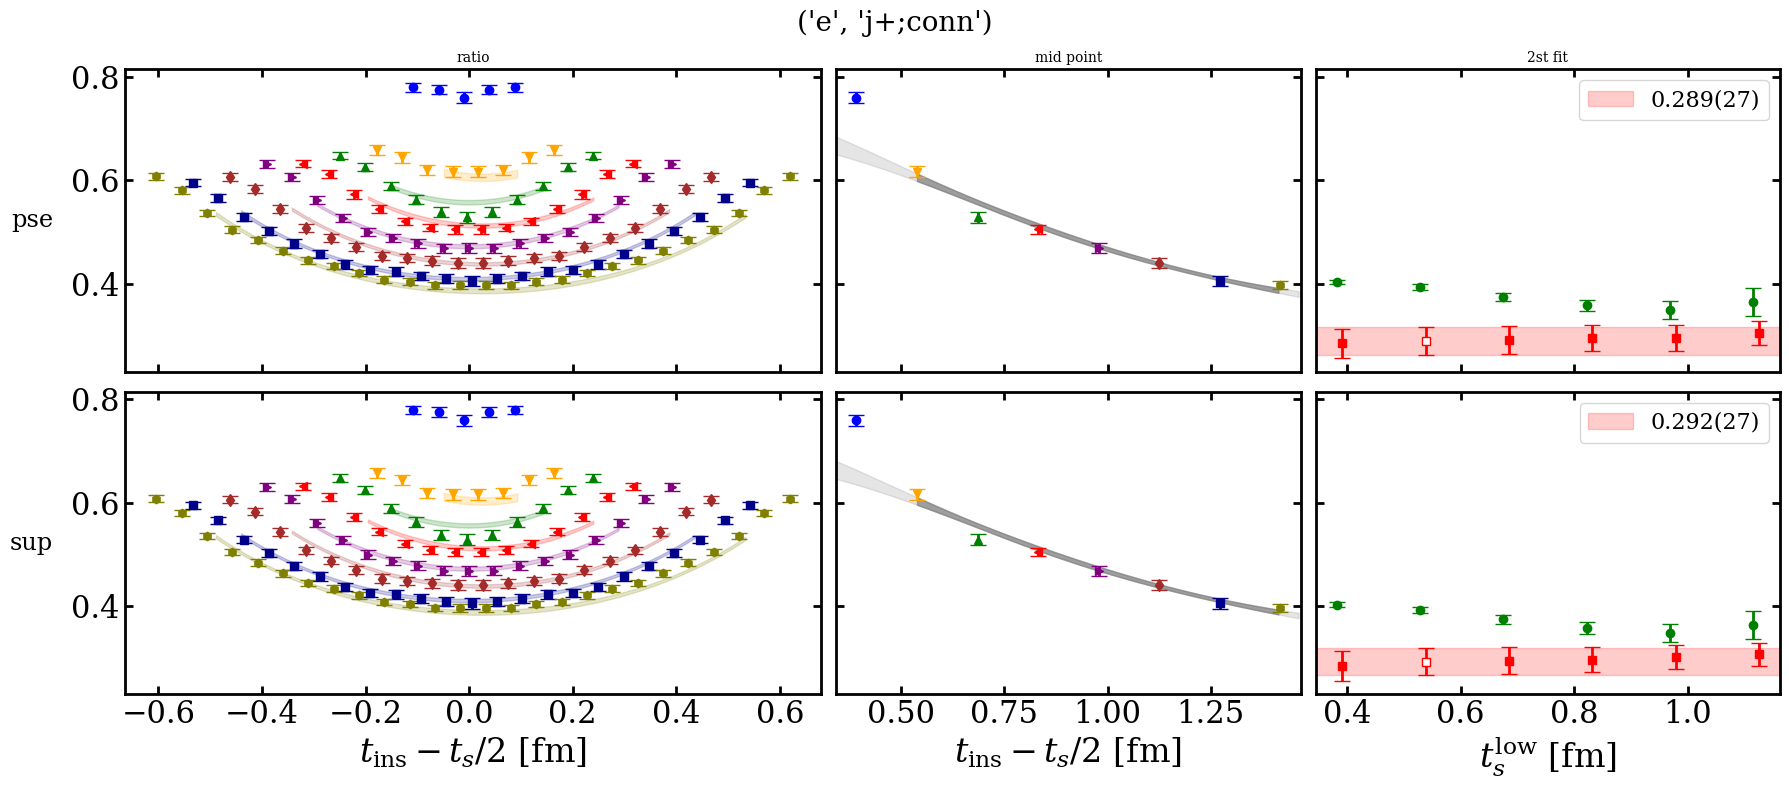

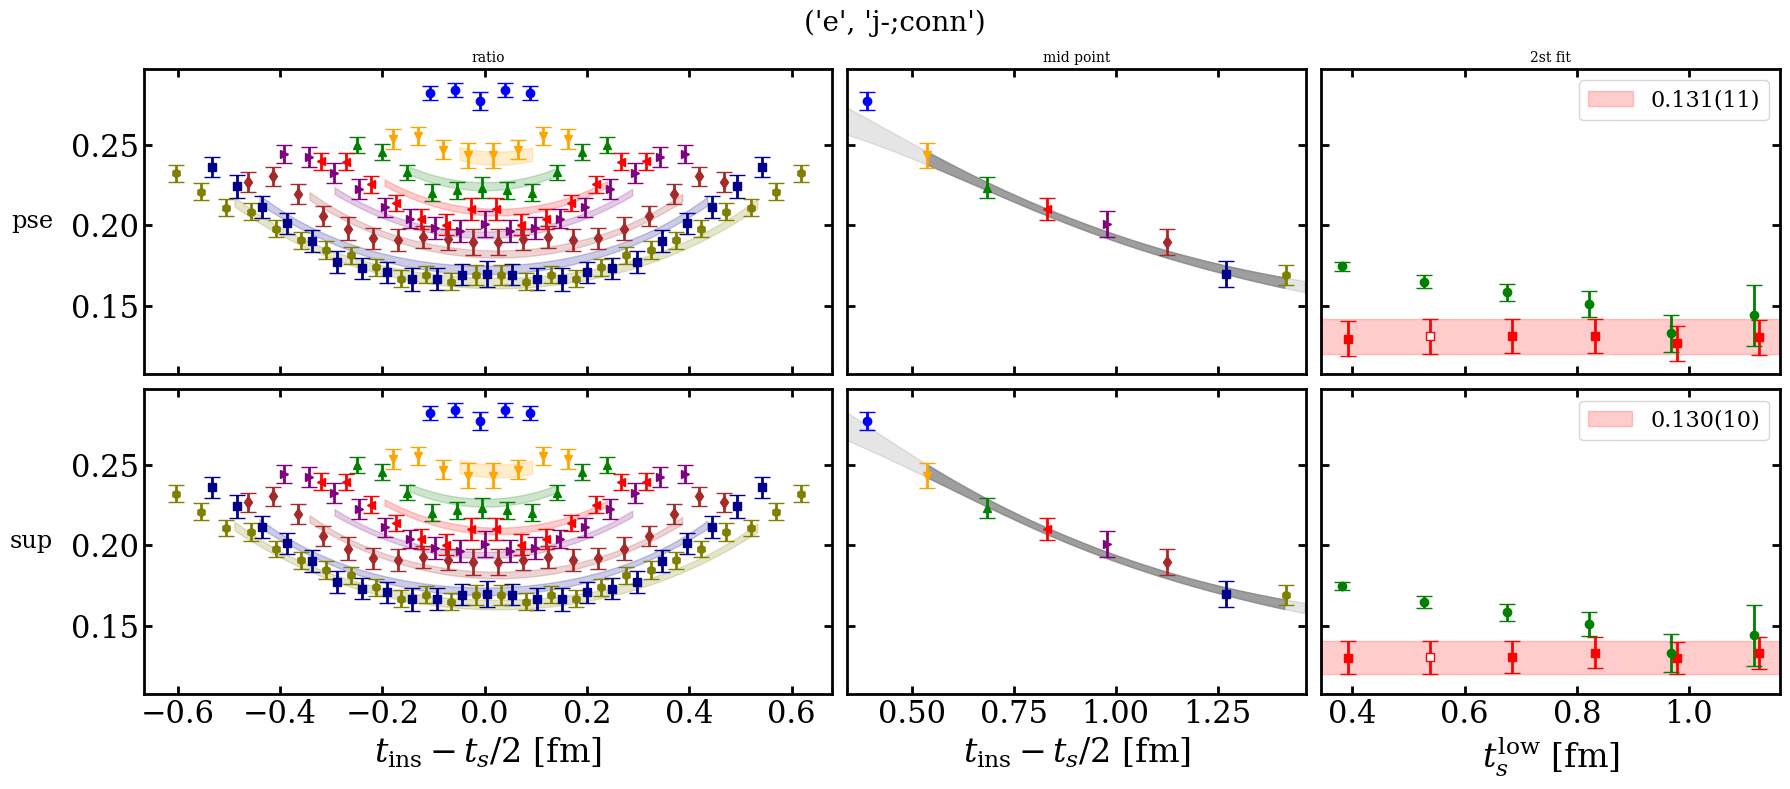

In [4]:

symmetrizeQ=True
def createDic(tf2ratio):
    tfmins=tfs[:-2]
    tcminss=[4]
    
    if symmetrizeQ:
        tf2ratio=yu.symmetrizeRatio(tf2ratio)
    
    fittype='2st2step_SYMshare'
    fits_sum=yu.doFits_3pt('sum',tf2ratio,tfmins,[2],corrQ=False)
    fits_2st=yu.doFits_3pt(fittype,tf2ratio,tfmins,tcminss,pars_jk_meff2st=pars_jk_meff2st,symmetrizeQ=symmetrizeQ)
    fit_2st_MA=yu.doMA_3pt(fits_2st,fitlabels=[(11,4)])
    pars_jk,probs_jk,fits=fit_2st_MA
    print(np.mean(pars_jk,axis=0))

    dic={
        'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[tf2ratio,None,None,fits_sum,fits_2st],
        'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,None,None,fit_2st_MA],
        'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,2,None],
        # 'fit_sum:[tfmin_min,tfmin_max,tcmin_min,tcmin_max,dtf,dtc]':[None,None,2,5,None,None],
        # 'fit_2st:[tfmin_min,tfmin_max,tcmin_min,tcmin_max,dtf,dtc]':[None,None,None,None,None,None],
        'fit_2st_rainbow_midpoint:[fittype,pars_jk_meff2st]':[fittype,pars_jk_meff2st],
        'xunit':yu.ens2a[ens],
    }
    dic_sum={
        'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[None,None,None,fits_sum,None],
        'fit_sum:[tfmin_min,tfmin_max,tcmin_min,tcmin_max,dtf,dtc]':[None,None,None,None,None,None],
        'xunit':yu.ens2a[ens],
        'shift:[rainbow,midpoint,fit]':[0,0,-0.2],
    }
    return dic,dic_sum

for key in keys:
    print(key)
    t1=createDic(key2tf2ratio_pseudo[key])
    t2=createDic(key2tf2ratio_sup[key])
    fig,axs=yu.makePlot_3pt([t1[0],t2[0]],shows=['rainbow','midpoint','fit_2st'],oddmidQ=True,sharey=True)
    fig,axs=yu.makePlot_3pt([t1[1],t2[1]],shows=['rainbow','rainbow','fit_sum'],figAxs=(fig,axs),colors_fit=['g'],fmts_fit=['o'],colHeaders=None)
    fig.suptitle(key)
    yu.addRowHeader(axs,['pse','sup'])
    yu.finalizePlot()

('e', 'j+;conn')


[0.27480077 0.4553627  0.19521164]
[0.27116613 0.46391597 0.15735383]
('e', 'j-;conn')
[0.12486153 0.16150558 0.07746783]
[0.12148475 0.16557911 0.09619621]


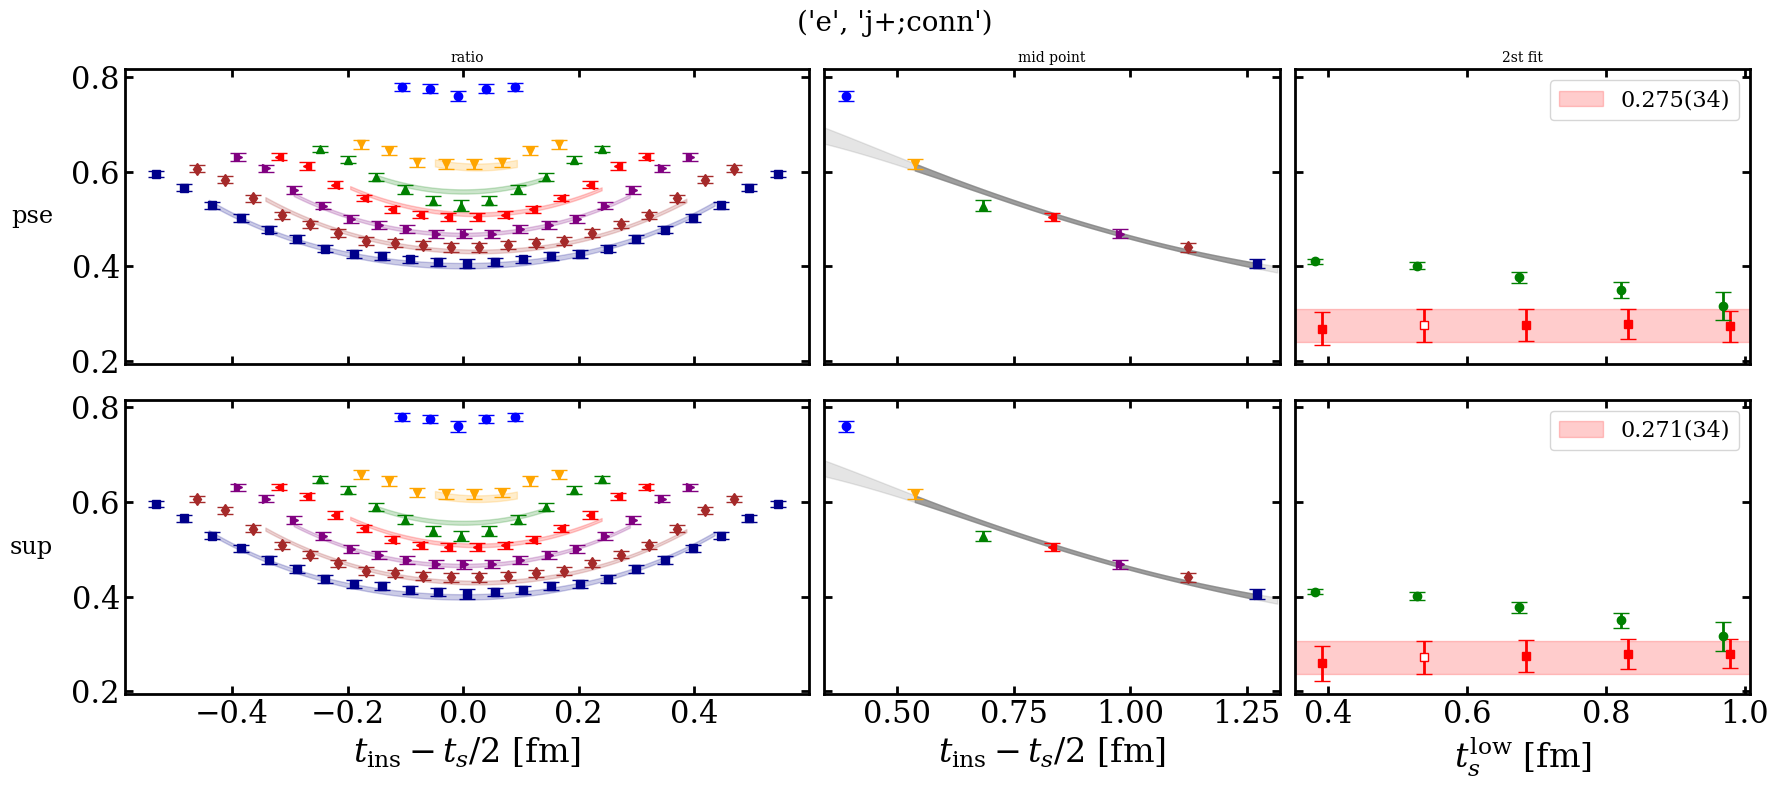

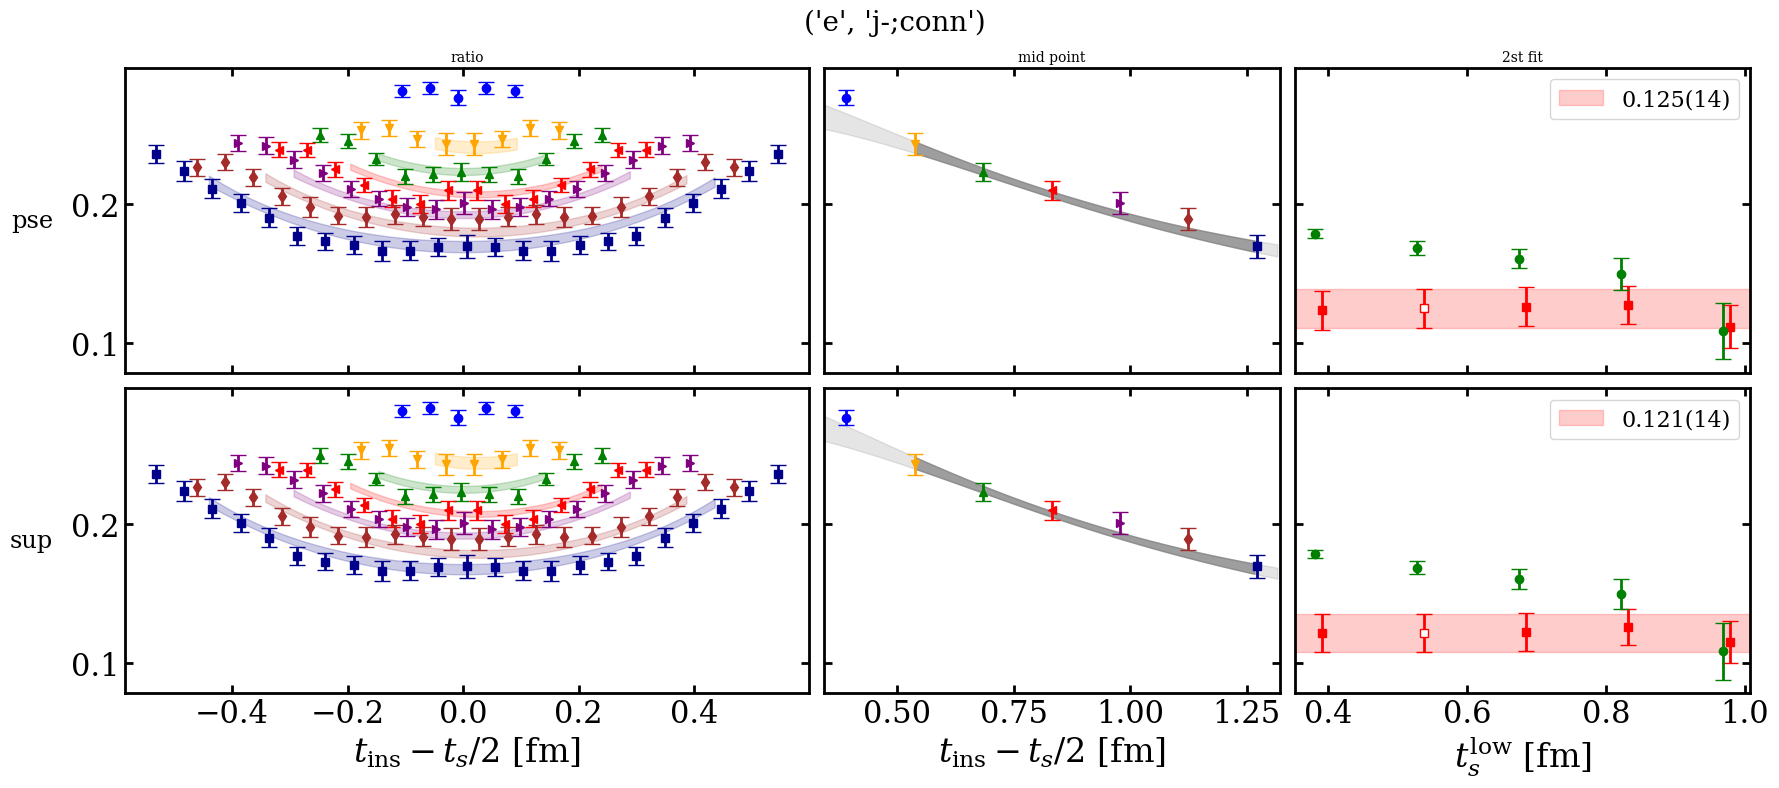

In [5]:
symmetrizeQ=True
def createDic(tf2ratio):
    tf2ratio={tf:tf2ratio[tf] for tf in tfs[:-1]}
    tfmins=tfs[:-3]
    tcminss=[4]
    
    if symmetrizeQ:
        tf2ratio=yu.symmetrizeRatio(tf2ratio)
    
    fittype='2st2step_SYMshare'
    fits_sum=yu.doFits_3pt('sum',tf2ratio,tfmins,[2],corrQ=False)
    fits_2st=yu.doFits_3pt(fittype,tf2ratio,tfmins,tcminss,pars_jk_meff2st=pars_jk_meff2st,symmetrizeQ=symmetrizeQ)
    fit_2st_MA=yu.doMA_3pt(fits_2st,fitlabels=[(11,4)])
    pars_jk,probs_jk,fits=fit_2st_MA
    print(np.mean(pars_jk,axis=0))

    dic={
        'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[tf2ratio,None,None,fits_sum,fits_2st],
        'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,None,None,fit_2st_MA],
        'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,2,None],
        # 'fit_sum:[tfmin_min,tfmin_max,tcmin_min,tcmin_max,dtf,dtc]':[None,None,2,5,None,None],
        # 'fit_2st:[tfmin_min,tfmin_max,tcmin_min,tcmin_max,dtf,dtc]':[None,None,None,None,None,None],
        'fit_2st_rainbow_midpoint:[fittype,pars_jk_meff2st]':[fittype,pars_jk_meff2st],
        'xunit':yu.ens2a[ens],
    }
    dic_sum={
        'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[None,None,None,fits_sum,None],
        'fit_sum:[tfmin_min,tfmin_max,tcmin_min,tcmin_max,dtf,dtc]':[None,None,None,None,None,None],
        'xunit':yu.ens2a[ens],
        'shift:[rainbow,midpoint,fit]':[0,0,-0.2],
    }
    return dic,dic_sum

for key in keys:
    print(key)
    t1=createDic(key2tf2ratio_pseudo[key])
    t2=createDic(key2tf2ratio_sup[key])
    fig,axs=yu.makePlot_3pt([t1[0],t2[0]],shows=['rainbow','midpoint','fit_2st'],oddmidQ=True,sharey=True)
    fig,axs=yu.makePlot_3pt([t1[1],t2[1]],shows=['rainbow','rainbow','fit_sum'],figAxs=(fig,axs),colors_fit=['g'],fmts_fit=['o'],colHeaders=None)
    fig.suptitle(key)
    yu.addRowHeader(axs,['pse','sup'])
    yu.finalizePlot()